In [1]:
!wsl curl -o dataset/produccion-agricola.json "https://www.datos.gov.co/resource/t2ca-uae5.json?\$limit=50000"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  399k    0  399k    0     0   291k      0 --:--:--  0:00:01 --:--:--  291k
100  911k    0  911k    0     0   376k      0 --:--:--  0:00:02 --:--:--  376k
100 1422k    0 1422k    0     0   411k      0 --:--:--  0:00:03 --:--:--  411k
100 2270k    0 2270k    0     0   519k      0 --:--:--  0:00:04 --:--:--  519k
100 3310k    0 3310k    0     0   616k      0 --:--:--  0:00:05 --:--:--  664k
100 4142k    0 4142k    0     0   651k      0 --:--:--  0:00:06 --:--:--  749k
100 4734k    0 4734k    0     0   644k      0 --:--:--  0:00:07 --:--:--  775k
100 5614k    0 5614k    0     0   672k      0 --:--:--  0:00:08 --:--:--  857k
100 5648k    0 5648k    0     0   673k      0 --:--

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
df = pd.read_json('dataset/produccion-agricola.json')
df.head()

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
0,Permanentes,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.0
1,Permanentes,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.0
2,Permanentes,Aguacate,Suroeste,1990,Montebello,17.0,12.0,78.0
3,Permanentes,Aguacate,Suroeste,1990,Santa Bárbara,150.0,140.0,980.0
4,Permanentes,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.0


In [6]:
df['tipo'].unique()

array(['Permanentes', 'Transitorios', 'Anuales'], dtype=object)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32721 entries, 0 to 32720
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tipo                32721 non-null  object 
 1   rubro               32721 non-null  object 
 2   subregion           32721 non-null  object 
 3   anio                32721 non-null  int64  
 4   municipio           32721 non-null  object 
 5   area_total          32680 non-null  float64
 6   area_produccion     32287 non-null  float64
 7   volumen_produccion  32535 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 2.0+ MB


In [15]:
df.describe()

,anio,area_total,area_produccion,volumen_produccion
count,32721.000000,32680.000000,32287.000000,3.253500e+04
mean,2009.716787,435.615817,399.454878,3.145023e+03
std,8.894551,1223.919511,1145.616547,2.322381e+04
min,1990.000000,0.000000,-1.000000,-1.065810e-14
25%,2003.000000,19.700000,15.000000,5.580000e+01
50%,2011.000000,76.000000,65.000000,2.880000e+02
75%,2017.000000,315.000000,285.000000,1.276000e+03
max,2022.000000,36000.000000,36000.000000,1.039280e+06


In [16]:
df.describe(include='O')

,tipo,rubro,subregion,municipio
count,32721,32721,32721,32721
unique,3,155,9,140
top,Permanentes,Café,Oriente,Medellín
freq,19753,2799,6802,732


In [14]:
df[df['tipo'] == 'Permanentes']['volumen_produccion'].mean()

3861.514644331663

In [17]:
df.duplicated().sum()

7

In [ ]:

df[df.duplicated()]

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
2268,Permanentes,Caña,Norte,1995,Guadalupe,267.0,262.0,1257.6
2554,Permanentes,Naranja,Occidente,1995,Olaya,11.8,7.3,149.2
2630,Permanentes,Plátano En Asocio,Norte,1995,Ituango,85.7,80.7,201.8
5292,Permanentes,Mora,Norte,1999,Yarumal,5.5,3.0,15.0
5432,Permanentes,Plátano En Asocio,Nordeste,1999,Vegachí,69.5,67.5,405.0
5435,Permanentes,Plátano En Asocio,Nordeste,1999,Yalí,85.0,63.0,535.5
13067,Permanentes,Plátano Monocultivo,Bajo Cauca,2008,El Bagre,90.0,90.0,720.0


([<matplotlib.patches.Wedge at 0x18fb677da10>,
 [Text(0.820063087950319, 0.7331415496214817, '2799'),
  Text(-0.5894772331671841, 0.9287177136124632, '2599'),
  Text(-1.0491676483710881, -0.33052571096887584, '2429'),
  Text(-0.0255130350089106, -1.0997040897644395, '2338'),
  Text(0.9693606407161898, -0.5199422547074802, '1889')],
 [Text(0.4473071388819922, 0.3998953907026263, '23.22%'),
  Text(-0.3215330362730095, 0.5065732983340708, '21.56%'),
  Text(-0.5722732627478662, -0.18028675143756864, '20.15%'),
  Text(-0.013916200913951236, -0.5998385944169669, '19.40%'),
  Text(0.5287421676633761, -0.2836048662040801, '15.67%')])

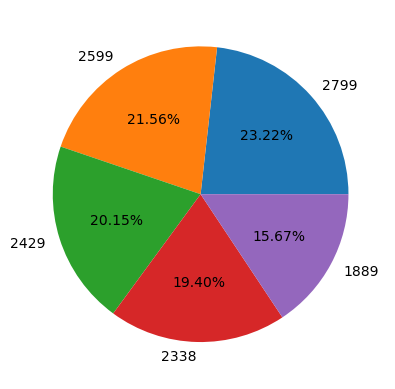

In [30]:
plt.pie(df['rubro'].value_counts().head(), labels=df['rubro'].value_counts().head().unique(), autopct='%0.2f%%')

<Axes: xlabel='rubro'>

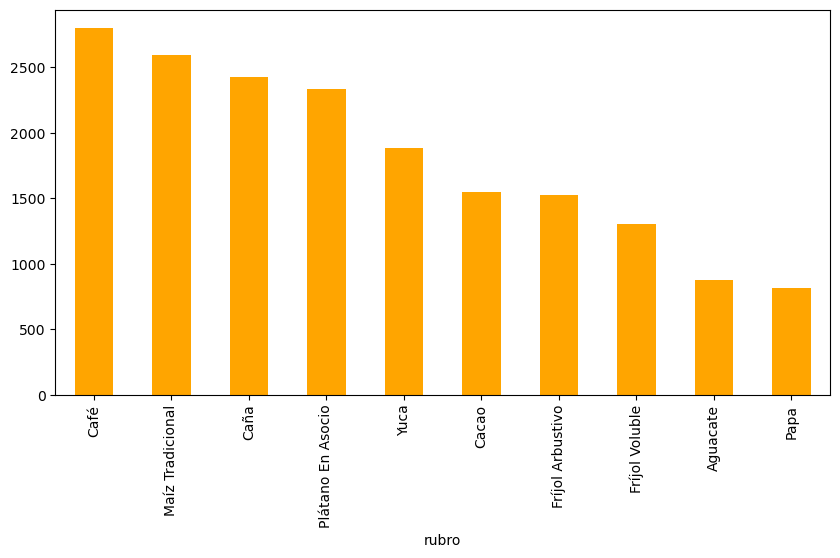

In [ ]:
plt.figure(figsize=(10, 10))
df['rubro'].value_counts().head(10).plot(kind='bar', colormap='Set2')
plt.title('Top 10 Rubros')

In [ ]:
sns.